Dataset:
   Hours  Marks
0      1     10
1      2     20
2      3     30
3      4     40
4      5     50
5      6     60
6      7     70
7      8     80
8      9     90
9     10    100

Linear Regression Results
-------------------------
Intercept: -7.105427357601002e-15
Coefficient: 10.000000000000002
Mean Squared Error: 6.310887241768095e-30
R2 Score: 1.0

Actual vs Predicted Marks:
   Actual Marks  Predicted Marks
0            90             90.0
1            20             20.0


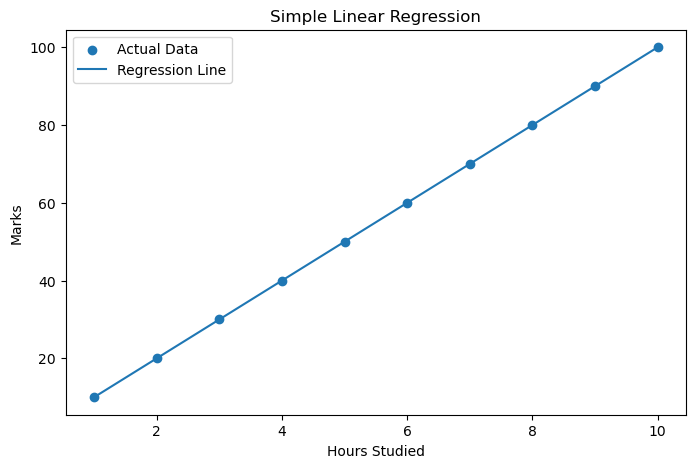


Enter hours studied:  2


Predicted marks for 2.0 hours studied: 20.00


In [1]:
# Simple Linear Regression
# Predicting Marks from Hours Studied

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Step 2: Create dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marks': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# Step 3: Define input and output
X = df[['Hours']]
y = df['Marks']


# Step 4: Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Step 5: Create Linear Regression model
model = LinearRegression()


# Step 6: Train the model
model.fit(X_train, y_train)


# Step 7: Predict test values
y_pred = model.predict(X_test)


# Step 8: Display model information
print("\nLinear Regression Results")
print("-------------------------")

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])


# Step 9: Calculate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# Step 10: Display actual vs predicted values
result = pd.DataFrame({
    'Actual Marks': y_test.values,
    'Predicted Marks': y_pred
})

print("\nActual vs Predicted Marks:")
print(result)


# Step 11: Graph
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    label='Regression Line'
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()


# Step 12: Custom prediction
custom_x = float(input("\nEnter hours studied: "))

custom_data = pd.DataFrame({
    'Hours': [custom_x]
})

custom_y = model.predict(custom_data)

print(
    f"Predicted marks for {custom_x} hours studied: "
    f"{custom_y[0]:.2f}"
)

In [2]:
#multiple linear regreesion
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('housing.csv')   # update path/filename as needed
print(df.head())
print(df.info())

# 2. Check missing values
print(df.isnull().sum())

# California housing has some missing 'total_bedrooms' values — fill with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 3. One-hot encode the categorical column
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 4. Define features (X) and target (y)
# Target column here is 'median_house_value'
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Fit multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)
print("Intercept:", model.intercept_)

# 8. Predictions
y_pred = model.predict(X_test)

# 9. Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

# 10. Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

--- STEP-BY-STEP REPORT ---
Dataset Means -> Maths: 6.0, Science: 5.0
Covariance Matrix:
[[8. 8.]
 [8. 8.]]
PC1 Vector Loadings: [0.70710678 0.70710678]
Calculated PC1 Scores: [-5.66 -2.83  0.    2.83  5.66]
SLR Formula: Science = 1.0 * Maths + (-1.0)
MLR Formula: Science = 0.1 + (0.8 * Maths) + (0.13 * PC1)


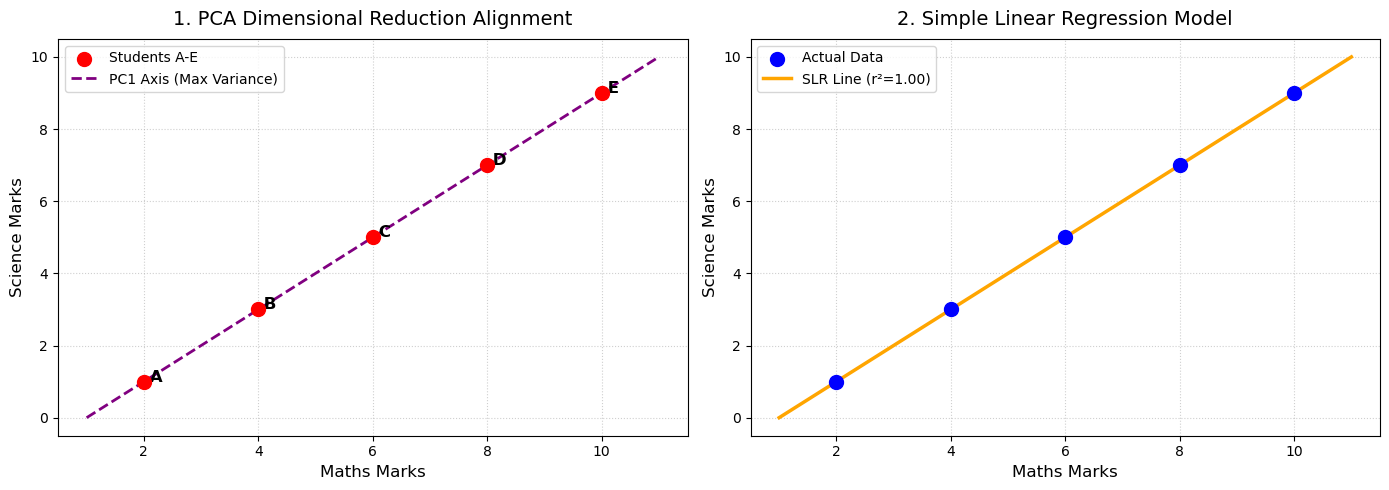

In [6]:
# problem 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
students = ['A', 'B', 'C', 'D', 'E']
maths = np.array([2, 4, 6, 8, 10])
science = np.array([1, 3, 5, 7, 9])
X_2d = np.stack((maths, science), axis=1)
mean_maths, mean_science = np.mean(maths), np.mean(science)
maths_centered = maths - mean_maths
science_centered = science - mean_science
X_centered = np.stack((maths_centered, science_centered), axis=1)
cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = eigenvalues.argsort()[::-1]
eigenvalues, eigenvectors = eigenvalues[idx], eigenvectors[:, idx]
pc1_loading = eigenvectors[:, 0]
pc1_scores = np.dot(X_centered, pc1_loading)
m_slr = cov_matrix[0, 1] / cov_matrix[0, 0]
c_slr = mean_science - (m_slr * mean_maths)
MLR_X = np.stack((np.ones(len(maths)), maths, pc1_scores), axis=1)
# Using pseudo-inverse (pinv) to gracefully handle collinearity in classrooms
beta_mlr = np.linalg.pinv(MLR_X.T @ MLR_X) @ MLR_X.T @ science
print("--- STEP-BY-STEP REPORT ---")
print(f"Dataset Means -> Maths: {mean_maths}, Science: {mean_science}")
print(f"Covariance Matrix:\n{cov_matrix}")
print(f"PC1 Vector Loadings: {pc1_loading}")
print(f"Calculated PC1 Scores: {np.round(pc1_scores, 2)}")
print(f"SLR Formula: Science = {m_slr:.1f} * Maths + ({c_slr:.1f})")
print(f"MLR Formula: Science = {beta_mlr[0]:.1f} + ({beta_mlr[1]:.1f} * Maths) + ({beta_mlr[2]:.2f} * PC1)")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(maths, science, color='red', s=100, zorder=5, label='Students A-E')
for i, txt in enumerate(students):
    ax1.annotate(f" {txt}", (maths[i], science[i]), fontsize=12, fontweight='bold')
x_vals = np.linspace(1, 11, 100)
pc1_slope = pc1_loading[1] / pc1_loading[0]
y_vals = mean_science + pc1_slope * (x_vals - mean_maths)
ax1.plot(x_vals, y_vals, '--', color='purple', linewidth=2, label='PC1 Axis (Max Variance)')

ax1.set_xlabel('Maths Marks', fontsize=12)
ax1.set_ylabel('Science Marks', fontsize=12)
ax1.set_title('1. PCA Dimensional Reduction Alignment', fontsize=14, pad=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

ax2.scatter(maths, science, color='blue', s=100, zorder=5, label='Actual Data')
y_pred_slr = m_slr * x_vals + c_slr
ax2.plot(x_vals, y_pred_slr, color='orange', linewidth=2.5, label=f'SLR Line (r²=1.00)')

ax2.set_xlabel('Maths Marks', fontsize=12)
ax2.set_ylabel('Science Marks', fontsize=12)
ax2.set_title('2. Simple Linear Regression Model', fontsize=14, pad=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


PC1 Variance Captured: 99.29%
SLR Formula: Science = 1.329 * Study_Hours + 0.425
MLR Formula: Science = 11.58 + (-0.74 * Study_Hours) + (1.24 * PC1)


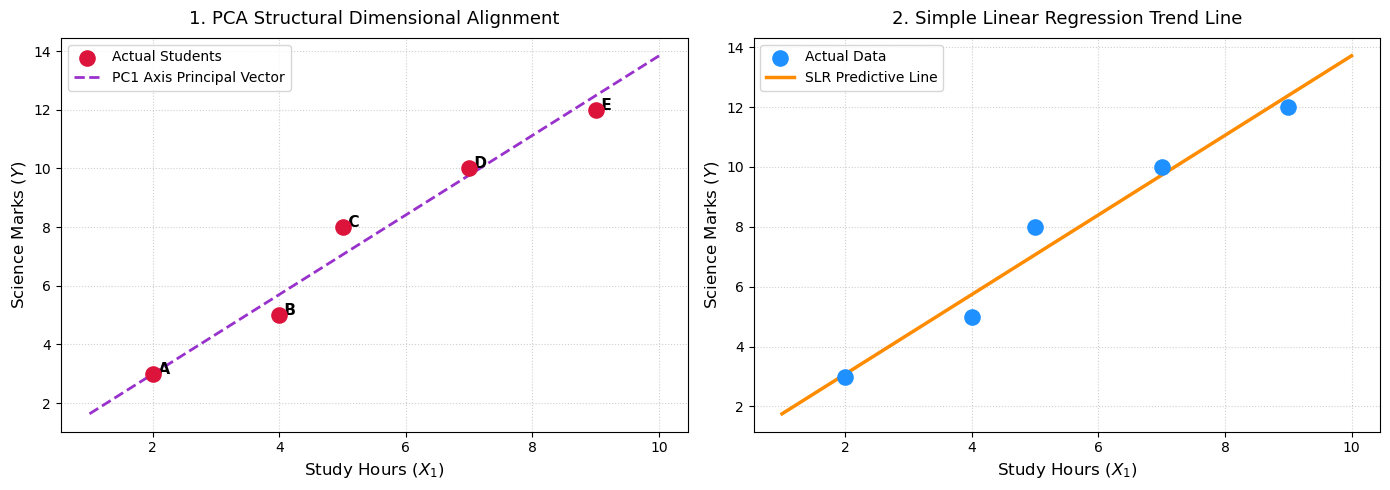

In [5]:
# prblm 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
students = ['A', 'B', 'C', 'D', 'E']
X1 = np.array([2, 4, 5, 7, 9])      
science = np.array([3, 5, 8, 10, 12])
X_2d = np.stack((X1, science), axis=1)
mean_vals = np.mean(X_2d, axis=0)
X_centered = X_2d - mean_vals
cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
idx = eig_vals.argsort()[::-1]
eig_vals, eig_vecs = eig_vals[idx], eig_vecs[:, idx]
pc1_scores = np.dot(X_centered, eig_vecs[:, 0])

m_slr = cov_matrix[0, 1] / cov_matrix[0, 0]
c_slr = mean_vals[1] - (m_slr * mean_vals[0])
X_design = np.stack((np.ones(len(X1)), X1, pc1_scores), axis=1)
beta_mlr = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ science

print(f"PC1 Variance Captured: {(eig_vals[0]/sum(eig_vals))*100:.2f}%")
print(f"SLR Formula: Science = {m_slr:.3f} * Study_Hours + {c_slr:.3f}")
print(f"MLR Formula: Science = {beta_mlr[0]:.2f} + ({beta_mlr[1]:.2f} * Study_Hours) + ({beta_mlr[2]:.2f} * PC1)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.scatter(X1, science, color='crimson', s=120, zorder=5, label='Actual Students')
for i, txt in enumerate(students):
    ax1.annotate(f" {txt}", (X1[i], science[i]), fontsize=11, fontweight='bold')

x_range = np.linspace(1, 10, 100)
pc1_slope = eig_vecs[1, 0] / eig_vecs[0, 0]
y_pc1_line = mean_vals[1] + pc1_slope * (x_range - mean_vals[0])
ax1.plot(x_range, y_pc1_line, '--', color='darkorchid', linewidth=2, label='PC1 Axis Principal Vector')

ax1.set_xlabel('Study Hours ($X_1$)', fontsize=12)
ax1.set_ylabel('Science Marks ($Y$)', fontsize=12)
ax1.set_title('1. PCA Structural Dimensional Alignment', fontsize=13, pad=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

ax2.scatter(X1, science, color='dodgerblue', s=120, zorder=5, label='Actual Data')
y_pred_slr = m_slr * x_range + c_slr
ax2.plot(x_range, y_pred_slr, color='darkorange', linewidth=2.5, label='SLR Predictive Line')

ax2.set_xlabel('Study Hours ($X_1$)', fontsize=12)
ax2.set_ylabel('Science Marks ($Y$)', fontsize=12)
ax2.set_title('2. Simple Linear Regression Trend Line', fontsize=13, pad=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


Regression Equation: Marks = 0.9 * Hours + (-0.6)
Predicted marks for 6 hours of study: 4.8


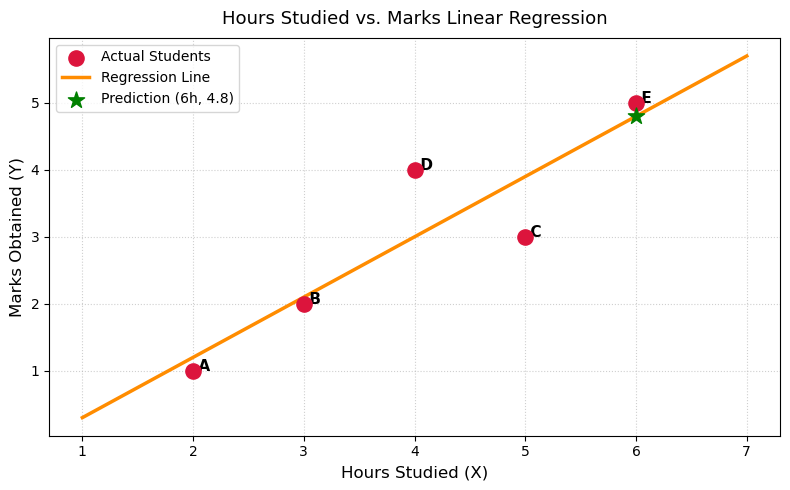

In [1]:
# prbm - 3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

students = ['A', 'B', 'C', 'D', 'E']
hours = np.array([2, 3, 5, 4, 6]).reshape(-1, 1)
marks = np.array([1, 2, 3, 4, 5])

model = LinearRegression()
model.fit(hours, marks)

m = model.coef_[0]
c = model.intercept_
print(f"Regression Equation: Marks = {m:.1f} * Hours + ({c:.1f})")

predicted_marks = model.predict([[6]])[0]
print(f"Predicted marks for 6 hours of study: {predicted_marks:.1f}")
plt.figure(figsize=(8, 5))

plt.scatter(hours, marks, color='crimson', s=120, zorder=5, label='Actual Students')
for i, txt in enumerate(students):
    plt.annotate(f" {txt}", (hours[i][0], marks[i]), fontsize=11, fontweight='bold')

x_line = np.linspace(1, 7, 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='darkorange', linewidth=2.5, label='Regression Line')

plt.scatter([6], [predicted_marks], color='green', s=150, marker='*', zorder=6, label=f'Prediction (6h, {predicted_marks:.1f})')

plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Marks Obtained (Y)', fontsize=12)
plt.title('Hours Studied vs. Marks Linear Regression', fontsize=13, pad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()